# 10 - EDA: automated profile

The original imported `pandas_profiling`, which is dead (renamed to `ydata-profiling` in 2023; the old name is now a stub that errors on import). This is a hand-rolled equivalent - overview, per-column stats, distributions, correlations, duplicate/constant checks, sample rows - in plain pandas + matplotlib. Reads `cleaned_v2.csv`; no output file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

raw = pd.read_csv('../data/interim/gurgaon_properties_cleaned_v2.csv')
df = raw.drop_duplicates()          # matches the original's .drop_duplicates()
df.shape

(3677, 23)

## 1. Dataset overview

In [2]:
n_rows, n_cols = df.shape
num_cols = df.select_dtypes('number').columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]
total_cells = n_rows * n_cols
missing_cells = int(df.isna().sum().sum())

overview = pd.Series({
    'rows': n_rows,
    'columns': n_cols,
    'numeric columns': len(num_cols),
    'categorical/text columns': len(cat_cols),
    'duplicate rows removed on load': len(raw) - len(df),
    'exact duplicate rows remaining': int(df.duplicated().sum()),
    'total cells': total_cells,
    'missing cells': missing_cells,
    'missing cells %': round(100 * missing_cells / total_cells, 2),
    'memory (MB)': round(df.memory_usage(deep=True).sum() / 1024**2, 2),
})
overview.to_frame('value')

,value
rows,3677.00
columns,23.00
numeric columns,16.00
categorical/text columns,7.00
duplicate rows removed on load,126.00
exact duplicate rows remaining,0.00
total cells,84571.00
missing cells,6710.00
missing cells %,7.93
memory (MB),2.03


## 2. Per-column summary

Type, non-null count, missing, cardinality, and the most frequent value for every column; distribution statistics for the numeric ones.

In [3]:
rows = []
for c in df.columns:
    s = df[c]
    nonnull = s.notna().sum()
    miss = s.isna().sum()
    vc = s.value_counts(dropna=True)
    top_val, top_freq = (vc.index[0], int(vc.iloc[0])) if len(vc) else (np.nan, 0)
    rows.append({
        'column': c,
        'dtype': str(s.dtype),
        'count': int(nonnull),
        'missing': int(miss),
        'missing %': round(100 * miss / len(s), 2),
        'unique': int(s.nunique(dropna=True)),
        'unique %': round(100 * s.nunique(dropna=True) / max(nonnull, 1), 2),
        'most frequent': top_val,
        'its count': top_freq,
    })
col_summary = pd.DataFrame(rows).set_index('column')
col_summary

,dtype,count,missing,missing %,unique,unique %,most frequent,its count
column,,,,,,,,
property_type,object,3677,0,0.00,2,0.05,flat,2818
society,object,3676,1,0.03,676,18.39,independent,486
sector,object,3677,0,0.00,104,2.83,sohna road,166
price,float64,3660,17,0.46,473,12.92,1.25,80
price_per_sqft,float64,3660,17,0.46,2651,72.43,10000.0,27
area,float64,3660,17,0.46,1312,35.85,1650.0,54
areaWithType,object,3677,0,0.00,2355,64.05,Plot area 360(301.01 sq.m.),37
bedRoom,int64,3677,0,0.00,19,0.52,3,1496
bathroom,int64,3677,0,0.00,19,0.52,3,1077


In [4]:
# Numeric distribution statistics
num_stats = df[num_cols].describe().T
num_stats['skew'] = df[num_cols].skew()
num_stats['kurtosis'] = df[num_cols].kurt()
num_stats['zeros'] = (df[num_cols] == 0).sum()
num_stats['negatives'] = (df[num_cols] < 0).sum()
num_stats.round(3)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,zeros,negatives
price,3660.0,2.534,2.981,0.07,0.95,1.52,2.75,31.5,3.279,14.933,0,0
price_per_sqft,3660.0,13892.668,23210.067,4.00,6817.25,9020.00,13880.50,600000.0,11.437,186.928,0,0
area,3660.0,2888.331,23167.506,50.00,1232.25,1733.00,2300.00,875000.0,29.731,942.029,0,0
bedRoom,3677.0,3.360,1.898,1.00,2.00,3.00,4.00,21.0,3.485,18.213,0,0
bathroom,3677.0,3.425,1.948,1.00,2.00,3.00,4.00,21.0,3.249,17.542,0,0
floorNum,3658.0,6.798,6.012,0.00,2.00,5.00,10.00,51.0,1.694,4.515,129,0
super_built_up_area,1875.0,1925.238,764.172,89.00,1479.50,1828.00,2215.00,10000.0,1.836,10.349,0,0
built_up_area,1690.0,2379.586,17942.880,2.00,1100.00,1650.00,2400.00,737147.0,40.707,1667.870,0,0
carpet_area,1872.0,2529.180,22799.836,15.00,843.00,1300.00,1790.00,607936.0,24.333,604.538,0,0
study room,3677.0,0.192,0.394,0.00,0.00,0.00,0.00,1.0,1.567,0.455,2972,0


## 3. Distributions

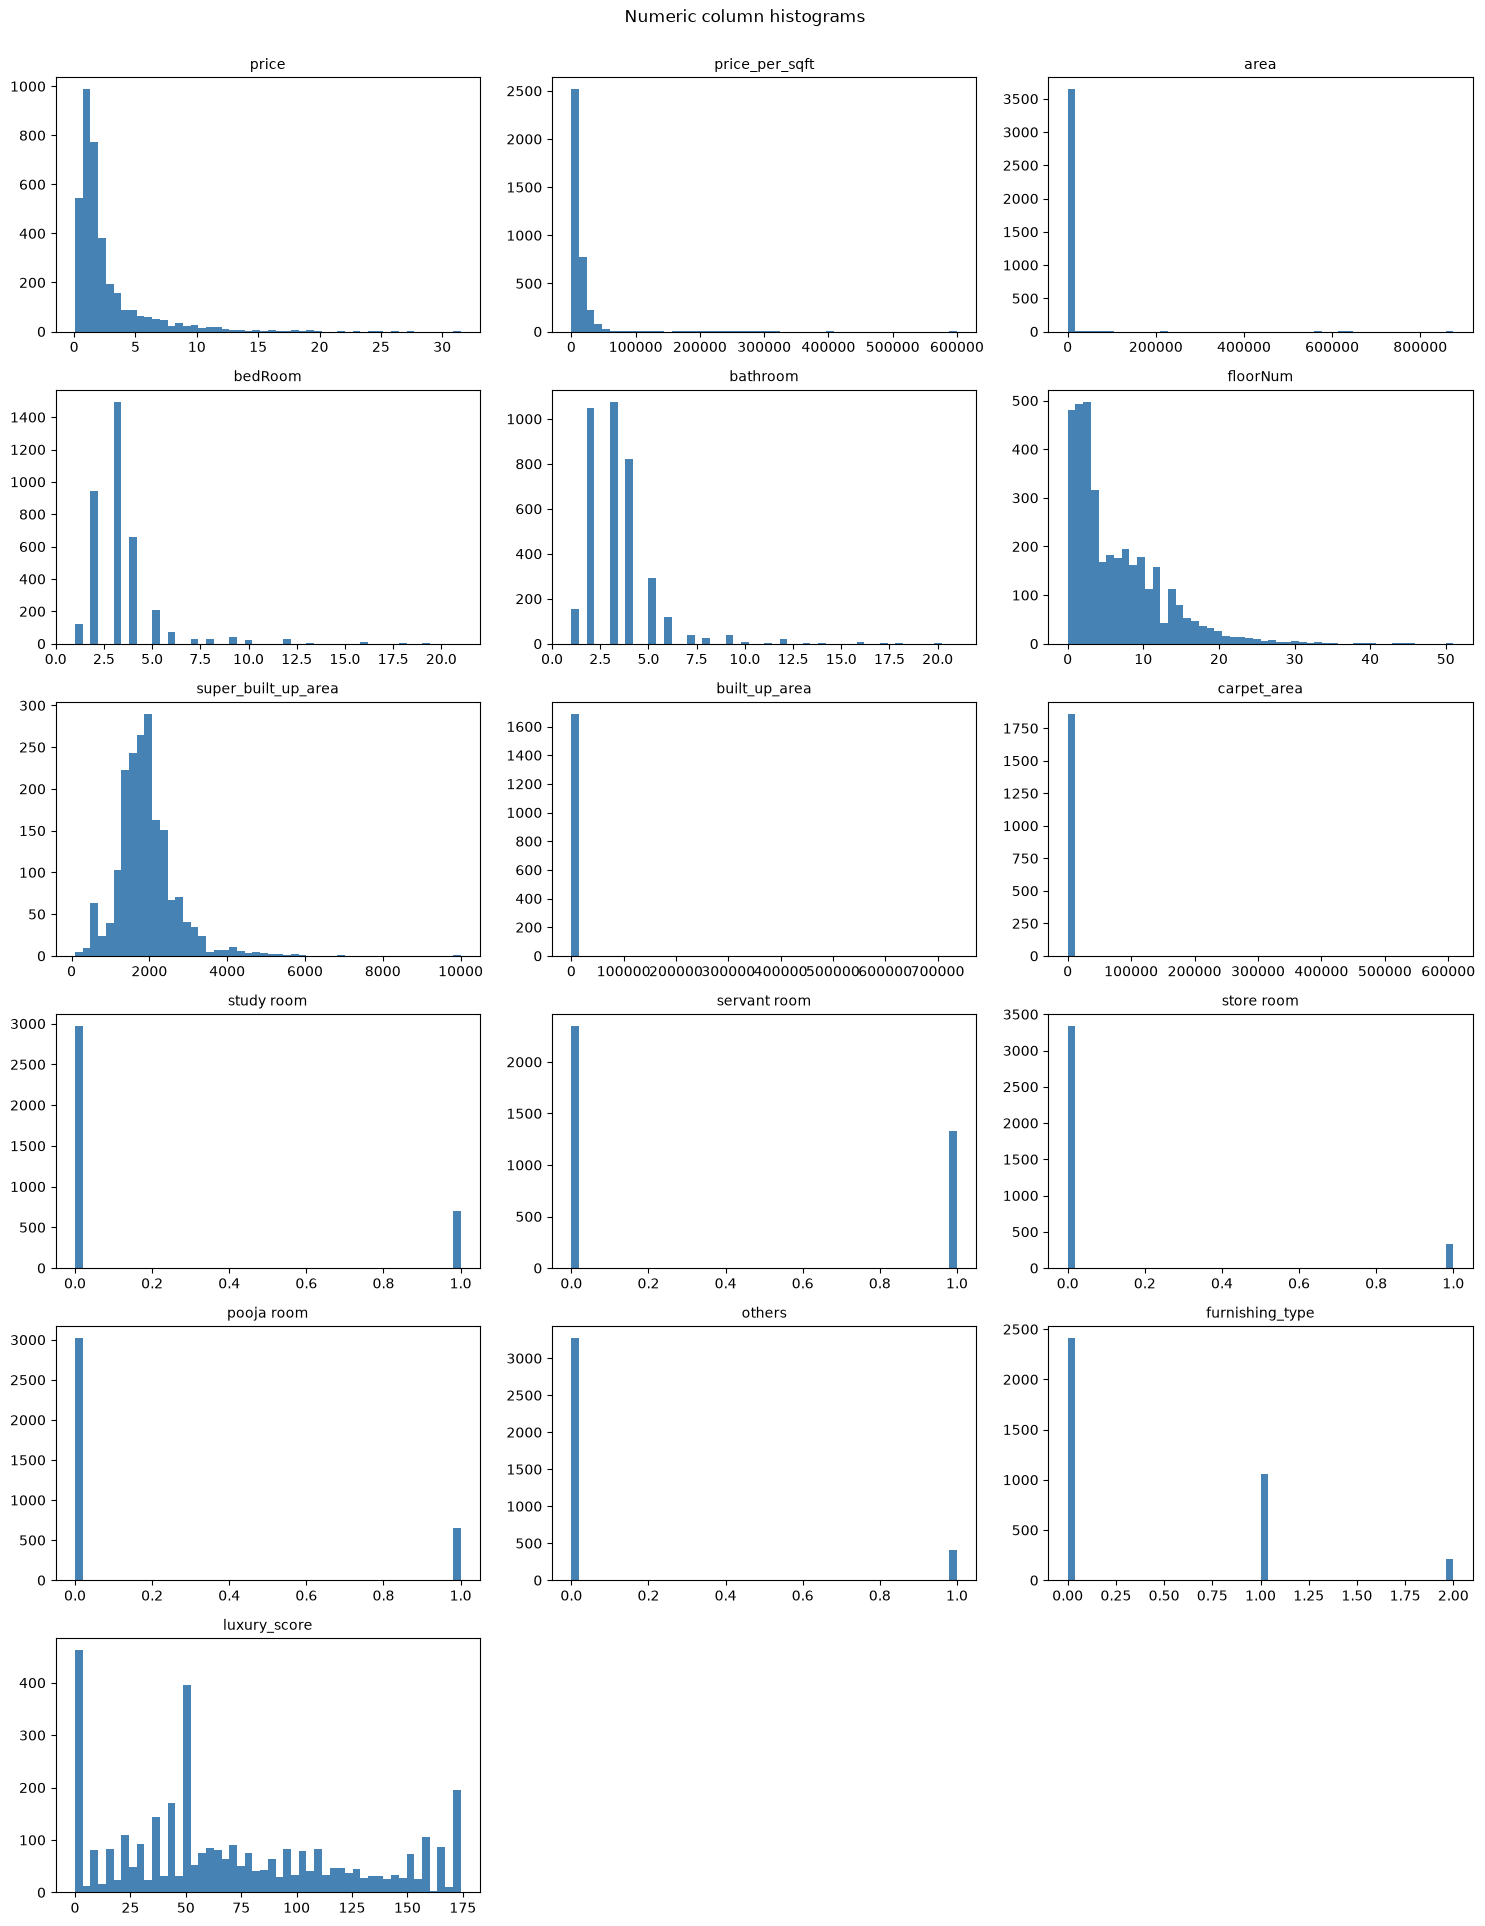

In [5]:
cols = num_cols
ncol = 3
nrow = int(np.ceil(len(cols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.2 * nrow))
for ax, c in zip(axes.ravel(), cols):
    ax.hist(df[c].dropna(), bins=50, color='steelblue')
    ax.set_title(c, fontsize=10)
for ax in axes.ravel()[len(cols):]:
    ax.set_visible(False)
fig.suptitle('Numeric column histograms', y=1.001)
fig.tight_layout()
plt.show()

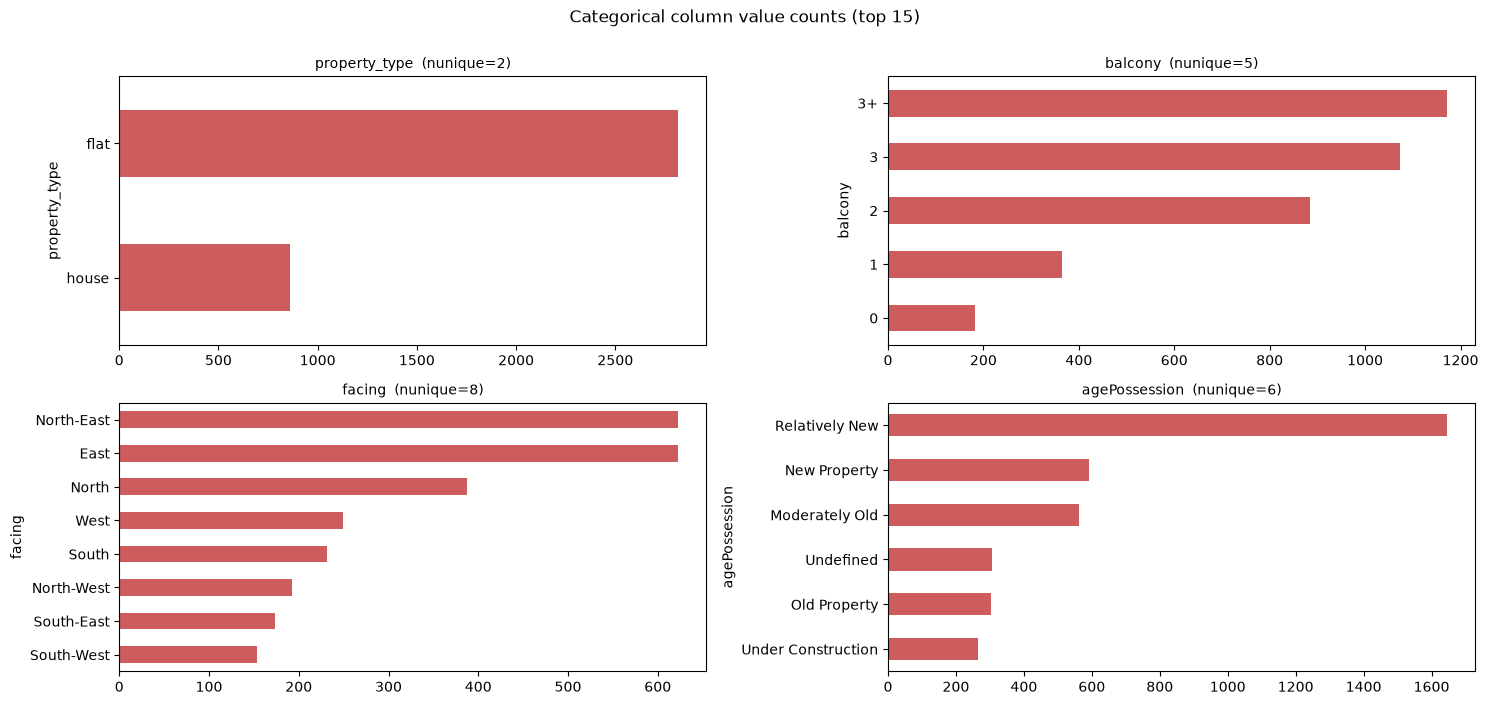

High-cardinality categoricals shown as counts only: {'society': 676, 'sector': 104, 'areaWithType': 2355}


In [6]:
# Low-cardinality categoricals: top-15 value counts
low_card = [c for c in cat_cols if df[c].nunique(dropna=True) <= 60]
ncol = 2
nrow = int(np.ceil(len(low_card) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.5 * nrow))
for ax, c in zip(np.atleast_1d(axes).ravel(), low_card):
    df[c].value_counts().head(15).iloc[::-1].plot(kind='barh', ax=ax, color='indianred')
    ax.set_title(f'{c}  (nunique={df[c].nunique()})', fontsize=10)
for ax in np.atleast_1d(axes).ravel()[len(low_card):]:
    ax.set_visible(False)
fig.suptitle('Categorical column value counts (top 15)', y=1.001)
fig.tight_layout()
plt.show()
print('High-cardinality categoricals shown as counts only:',
      {c: df[c].nunique() for c in cat_cols if c not in low_card})

## 4. Correlations

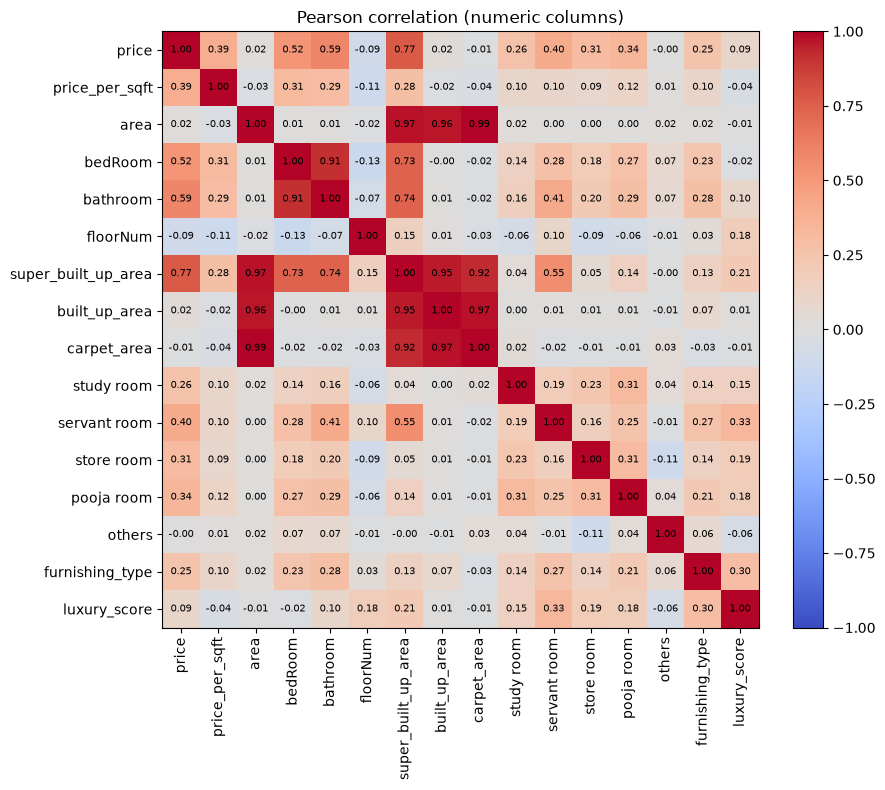

In [7]:
corr = df[num_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for (i, j), v in np.ndenumerate(corr.values):
    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('Pearson correlation (numeric columns)')
fig.tight_layout()
plt.show()

In [8]:
# Strongest correlated pairs (|r| >= 0.5, excluding self)
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().rename('r').reset_index())
pairs['|r|'] = pairs['r'].abs()
pairs[pairs['|r|'] >= 0.5].sort_values('|r|', ascending=False).reset_index(drop=True)

,level_0,level_1,r,|r|
0,area,carpet_area,0.992773,0.992773
1,built_up_area,carpet_area,0.972033,0.972033
2,area,super_built_up_area,0.968765,0.968765
3,area,built_up_area,0.964540,0.964540
4,super_built_up_area,built_up_area,0.954333,0.954333
5,super_built_up_area,carpet_area,0.924138,0.924138
6,bedRoom,bathroom,0.908884,0.908884
7,price,super_built_up_area,0.769412,0.769412
8,bathroom,super_built_up_area,0.740212,0.740212
9,bedRoom,super_built_up_area,0.734787,0.734787


## 5. Missing values

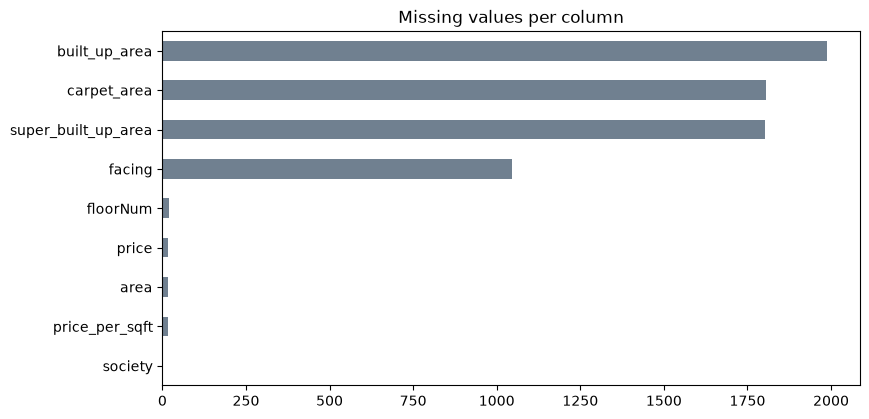

,missing,missing %
built_up_area,1987,54.04
carpet_area,1805,49.09
super_built_up_area,1802,49.01
facing,1045,28.42
floorNum,19,0.52
price,17,0.46
area,17,0.46
price_per_sqft,17,0.46
society,1,0.03


In [9]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
if len(miss):
    ax = miss.plot(kind='barh', figsize=(9, 0.4 * len(miss) + 1), color='slategray')
    ax.set_title('Missing values per column')
    ax.invert_yaxis()
    plt.show()
(miss.to_frame('missing')
     .assign(**{'missing %': (100 * miss / len(df)).round(2)}))

## 6. Duplicate & constant columns

In [10]:
print('Exact duplicate rows:', int(df.duplicated().sum()))

constant = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print('Constant columns (<=1 unique value):', constant or 'none')

near_const = {c: round(100 * df[c].value_counts(normalize=True, dropna=False).iloc[0], 2)
              for c in df.columns
              if df[c].value_counts(normalize=True, dropna=False).iloc[0] >= 0.99}
print('Near-constant columns (>=99% one value):', near_const or 'none')

hi_corr = pairs[pairs['|r|'] >= 0.9][['level_0', 'level_1', 'r']]
print('Highly correlated column pairs (|r| >= 0.9):')
hi_corr.reset_index(drop=True)

Exact duplicate rows: 0
Constant columns (<=1 unique value): none
Near-constant columns (>=99% one value): none
Highly correlated column pairs (|r| >= 0.9):


,level_0,level_1,r
0,area,super_built_up_area,0.968765
1,area,built_up_area,0.964540
2,area,carpet_area,0.992773
3,bedRoom,bathroom,0.908884
4,super_built_up_area,built_up_area,0.954333
5,super_built_up_area,carpet_area,0.924138
6,built_up_area,carpet_area,0.972033


## 7. Sample rows

In [11]:
df.head(10)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,17.0,NaN,New Property,NaN,1000.00,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,10.0,North-West,Relatively New,1995.0,1615.00,1476.0,0,1,0,0,1,1,174
5,flat,suncity avenue,sector 102,0.48,9022.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2,2,1,5.0,North-East,Relatively New,632.0,NaN,532.0,0,0,1,0,0,0,159
6,flat,paras quartier,gwal pahari,7.50,14018.0,5350.0,Super Built up area 5350(497.03 sq.m.),4,4,3+,20.0,North-East,New Property,5350.0,NaN,NaN,0,1,0,1,1,1,49
7,flat,experion the heartsong,sector 108,2.00,8554.0,2338.0,Super Built up area 2338(217.21 sq.m.),3,3,3+,14.0,East,Relatively New,2338.0,NaN,NaN,0,1,0,0,0,0,95
8,flat,adani m2k oyster grande,sector 102,1.90,9105.0,2087.0,Super Built up area 1889(175.49 sq.m.),3,4,3,8.0,North-East,Relatively New,1889.0,NaN,NaN,0,1,0,0,0,0,165
9,house,independent,sector 105,1.20,10122.0,1186.0,Plot area 1185.51(110.14 sq.m.),6,2,1,2.0,North-West,Old Property,NaN,1185.51,NaN,0,0,0,0,0,0,9


In [12]:
df.sample(10, random_state=42)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2170,flat,antriksh heights,sector 84,0.85,4927.0,1725.0,Super Built up area 1725(160.26 sq.m.),3,3,3+,10.0,North,Relatively New,1725.0,NaN,NaN,1,0,0,0,0,0,52
1778,flat,la vida by tata housing,sector 113,2.33,12533.0,1859.0,Super Built up area 2217(205.97 sq.m.)Built Up...,3,3,3,3.0,North,New Property,2217.0,2098.0,1859.000000,0,1,0,0,0,0,174
3787,flat,deepak minda,manesar,1.20,4528.0,2650.0,Carpet area: 2650 (246.19 sq.m.),3,3,3+,6.0,North-West,Moderately Old,NaN,NaN,2650.000000,0,1,0,0,0,0,7
2922,house,independent,sector 9,0.50,6083.0,822.0,Built Up area: 822 (76.37 sq.m.)Carpet area: 7...,3,2,1,1.0,NaN,Undefined,NaN,822.0,750.000000,0,0,0,0,0,0,0
1724,flat,signature global orchard avenue,sector 93,0.38,6387.0,595.0,Carpet area: 594.91 (55.27 sq.m.),2,2,2,7.0,North,Relatively New,NaN,NaN,594.920753,0,0,0,0,0,0,16
514,house,independent,sector 25,9.00,28490.0,3159.0,Plot area 351(293.48 sq.m.),10,10,3,3.0,East,Old Property,NaN,3159.0,NaN,0,0,0,1,0,1,64
2355,flat,vatika the seven lamps,sector 82,1.60,6597.0,2425.0,Super Built up area 2425(225.29 sq.m.),4,5,3+,8.0,South-West,Relatively New,2425.0,NaN,NaN,0,1,0,0,0,0,133
3135,flat,pyramid urban homes 2,sector 86,0.43,8582.0,501.0,Carpet area: 501 (46.54 sq.m.),2,2,1,6.0,North-East,New Property,NaN,NaN,501.000000,1,0,0,0,0,0,92
2314,house,independent,sector 41,7.25,29293.0,2475.0,Plot area 275(229.94 sq.m.),9,8,3,4.0,South-West,Old Property,NaN,2475.0,NaN,0,1,0,0,0,1,94
230,flat,ramsons kshitij,sector 95,0.29,5178.0,560.0,Super Built up area 560(52.03 sq.m.),2,2,2,14.0,NaN,Relatively New,560.0,NaN,NaN,0,0,0,0,0,0,50


In [13]:
df.tail(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3798,flat,pivotal devaan,sector 84,0.37,6346.0,583.0,Super Built up area 583(54.16 sq.m.)Carpet are...,2,2,1,5.0,North-West,Relatively New,583.0,NaN,483.0,0,0,0,0,0,0,73
3799,house,international city by sobha phase 1,sector 109,6.00,9634.0,6228.0,Plot area 692(578.6 sq.m.),5,5,3+,2.0,South-West,Relatively New,NaN,6228.0,NaN,1,1,1,1,0,0,160
3800,flat,ansal api celebrity suites,sector 2,0.60,8163.0,735.0,Super Built up area 735(68.28 sq.m.),1,1,1,5.0,North-East,Moderately Old,735.0,NaN,NaN,0,0,0,0,0,1,67
3801,house,independent,sector 43,15.50,28233.0,5490.0,Plot area 610(510.04 sq.m.),5,6,3,3.0,East,Moderately Old,NaN,5490.0,NaN,1,1,1,1,0,0,76
3802,flat,m3m ikonic,sector 68,1.78,9128.0,1950.0,Super Built up area 1950(181.16 sq.m.)Built Up...,3,3,3+,27.0,South,Relatively New,1950.0,1845.0,1530.0,0,0,0,0,0,1,126
